<a href="https://colab.research.google.com/github/mayank261193/Session-7-Visualisation/blob/main/Session7_FollowAlong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 7 — Visualisation & Data Acquisition
### For Policy, Governance & UPSC Learners

In Session 6 you cleaned and combined tables with Pandas. Today you turn those tables into **charts** that tell a story, and you learn to **acquire** fresh data from the internet — from a public API and by scraping a web table. Detailed theory is in the PPT slides — this notebook is code-first, so run every cell yourself.

### Learning objectives
By the end of this session you will be able to:

- Draw core charts with **Matplotlib** (line, bar, scatter, histogram, box).
- Choose the **right chart** for a question, and make quick charts with **Seaborn**.
- Build **interactive** charts with **Plotly**.
- Combine several charts into a simple **data story**.
- Pull data from a **REST API** using `requests`.
- **Scrape** a simple HTML table with `BeautifulSoup`.

*(We'll reuse `groupby()` from Session 6 to prepare data for a few charts — but we won't re-teach it.)*

> **Note:** The datasets used in this notebook are fictional but inspired by real government reporting formats. They are intended solely for learning visualisation and data acquisition and should not be treated as actual government statistics.

---

## 1. Creating the Datasets

We build two small UPSC-themed datasets in code and save them as CSVs, so this notebook runs top to bottom on its own.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)   # keeps everything reproducible on Run All

# Dataset 1 — state-level development indicators.
state_development = pd.DataFrame({
    "State": ["Maharashtra", "Kerala", "Bihar", "Rajasthan", "Assam", "Odisha",
              "Karnataka", "Gujarat", "Tamil Nadu", "Punjab", "Madhya Pradesh",
              "Uttar Pradesh", "West Bengal"],
    "LiteracyRate": [82.3, 96.2, 70.9, 66.1, 85.9, 77.3, 77.2, 79.3, 82.9, 76.7, 70.6, 69.7, 77.1],
    "ForestCover": [16.5, 52.3, 7.2, 4.8, 36.1, 33.5, 20.2, 7.6, 20.3, 3.6, 25.1, 9.2, 18.9],
    "RenewableEnergy": [10500, 3200, 450, 12800, 180, 900, 8600, 15400, 15600, 1600, 5800, 3900, 1100],
    "PopulationDensity": [365, 860, 1102, 200, 398, 270, 319, 308, 555, 551, 236, 829, 1028],
    "Rainfall": [2200, 3000, 1200, 550, 2300, 1450, 1150, 800, 1000, 650, 1100, 1000, 1750],
})
state_development.to_csv("state_development.csv", index=False)
print("Saved state_development.csv:", state_development.shape)
state_development.head()

Saved state_development.csv: (13, 6)


,State,LiteracyRate,ForestCover,RenewableEnergy,PopulationDensity,Rainfall
0,Maharashtra,82.3,16.5,10500,365,2200
1,Kerala,96.2,52.3,3200,860,3000
2,Bihar,70.9,7.2,450,1102,1200
3,Rajasthan,66.1,4.8,12800,200,550
4,Assam,85.9,36.1,180,398,2300


In [2]:
# Dataset 2 — district-level healthcare data.
district_healthcare = pd.DataFrame({
    "District": ["Pune", "Nagpur", "Kochi", "Thiruvananthapuram", "Patna", "Gaya",
                 "Jaipur", "Guwahati", "Cuttack", "Bhubaneswar", "Mysuru", "Bengaluru",
                 "Ahmedabad", "Surat", "Chennai"],
    "State": ["Maharashtra", "Maharashtra", "Kerala", "Kerala", "Bihar", "Bihar",
              "Rajasthan", "Assam", "Odisha", "Odisha", "Karnataka", "Karnataka",
              "Gujarat", "Gujarat", "Tamil Nadu"],
    "Hospitals": [45, 38, 52, 48, 30, 22, 40, 33, 28, 35, 26, 60, 55, 44, 58],
    "PHCs": [120, 95, 140, 130, 70, 55, 100, 80, 68, 85, 60, 160, 150, 110, 155],
    "Doctors": [3200, 2100, 3800, 3500, 1500, 900, 2600, 1700, 1300, 2000, 1200, 5200, 4300, 3100, 4800],
    "Population": [3150000, 2460000, 2100000, 1900000, 2050000, 1600000, 3070000, 1120000,
                   1650000, 1400000, 1250000, 8400000, 5570000, 4460000, 4640000],
    "LiteracyRate": [86.5, 84.2, 95.1, 95.8, 70.4, 66.3, 76.4, 88.5, 84.7, 84.7, 79.3, 88.7, 88.3, 87.9, 90.2],
})
district_healthcare.to_csv("district_healthcare.csv", index=False)
print("Saved district_healthcare.csv:", district_healthcare.shape)
district_healthcare.head()

Saved district_healthcare.csv: (15, 7)


,District,State,Hospitals,PHCs,Doctors,Population,LiteracyRate
0,Pune,Maharashtra,45,120,3200,3150000,86.5
1,Nagpur,Maharashtra,38,95,2100,2460000,84.2
2,Kochi,Kerala,52,140,3800,2100000,95.1
3,Thiruvananthapuram,Kerala,48,130,3500,1900000,95.8
4,Patna,Bihar,30,70,1500,2050000,70.4


**Takeaway:** Both datasets now live as CSVs we can load and chart throughout the notebook.

---

## 2. Matplotlib Basics

Matplotlib is the core plotting library — `import matplotlib.pyplot as plt`, draw, then `plt.show()`. We'll load the state data and make five basic charts.

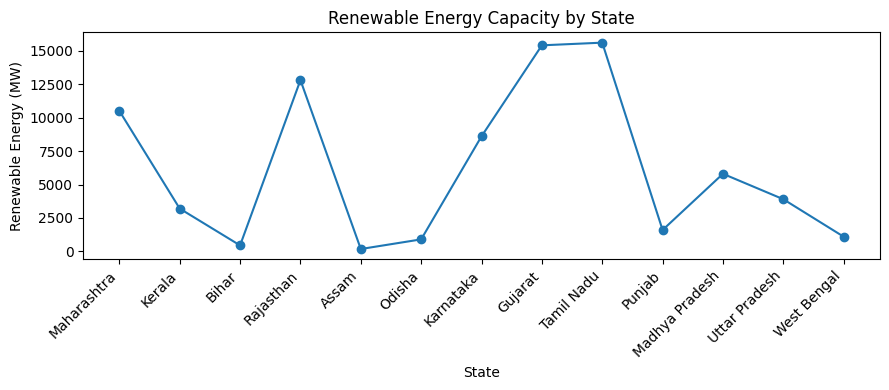

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

states = pd.read_csv("state_development.csv")


# LINE CHART — renewable energy across states.
plt.figure(figsize=(9, 4))
plt.plot(states["State"], states["RenewableEnergy"], marker="o")
plt.title("Renewable Energy Capacity by State")
plt.xlabel("State")
plt.ylabel("Renewable Energy (MW)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Takeaway:** A line chart connects points in order — useful for showing a sequence or trend.

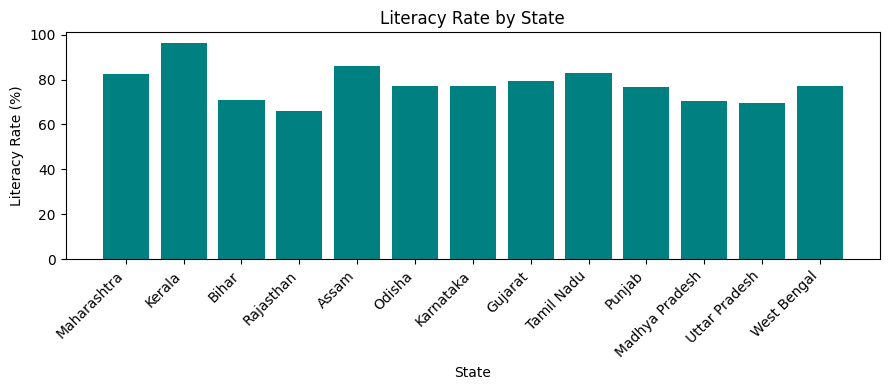

In [4]:
# BAR CHART — literacy rate by state (best for comparing categories).
plt.figure(figsize=(9, 4))
plt.bar(states["State"], states["LiteracyRate"], color="teal")
plt.title("Literacy Rate by State")
plt.xlabel("State")
plt.ylabel("Literacy Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Takeaway:** Bars compare a value across categories — the clearest way to rank states.

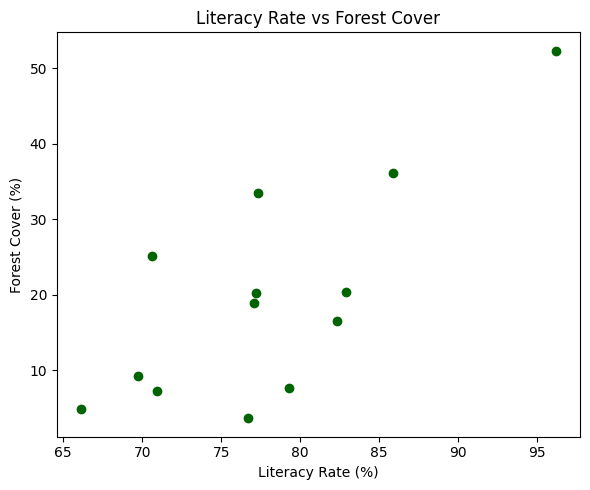

In [5]:
# SCATTER PLOT — is higher literacy linked to more forest cover?
plt.figure(figsize=(6, 5))
plt.scatter(states["LiteracyRate"], states["ForestCover"], color="darkgreen")
plt.title("Literacy Rate vs Forest Cover")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Forest Cover (%)")
plt.tight_layout()
plt.show()

**Takeaway:** A scatter plot shows the relationship between two numeric columns.

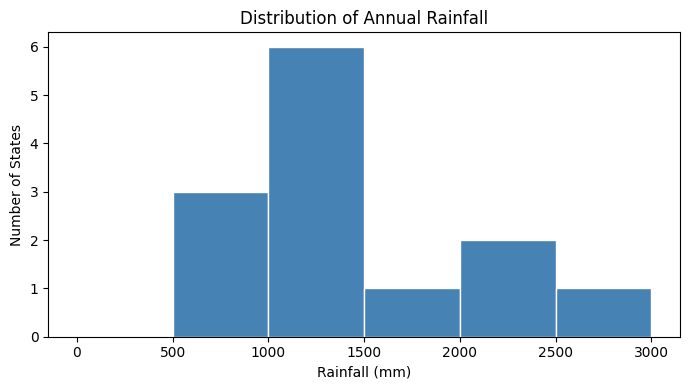

In [6]:
# HISTOGRAM — how rainfall is distributed across states.
plt.figure(figsize=(7, 4))
plt.hist(states["Rainfall"], bins=[0, 500, 1000, 1500, 2000, 2500, 3000],color="steelblue", edgecolor="white")
plt.title("Distribution of Annual Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Number of States")
plt.tight_layout()
plt.show()

**Takeaway:** A histogram groups values into bins to show their distribution.

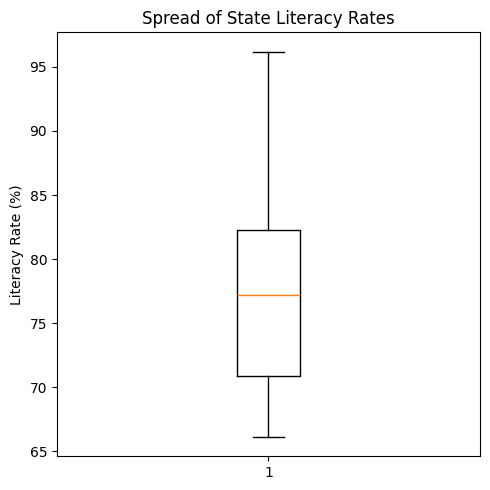

In [7]:
# BOX PLOT — the spread of literacy rates (median, range, outliers).
plt.figure(figsize=(5, 5))
plt.boxplot(states["LiteracyRate"], vert=True)
plt.title("Spread of State Literacy Rates")
plt.ylabel("Literacy Rate (%)")
plt.tight_layout()
plt.show()

**Takeaway:** A box plot summarises a column's middle, spread, and any outliers at a glance.

---

## 3. Choosing the Right Chart

Pick the chart that matches your question: **bar** to compare categories, **line** for a trend/sequence, **scatter** for a relationship, **histogram** for a distribution, and **pie** for parts of a whole.

In [8]:
health = pd.read_csv("district_healthcare.csv")
health.head()

,District,State,Hospitals,PHCs,Doctors,Population,LiteracyRate
0,Pune,Maharashtra,45,120,3200,3150000,86.5
1,Nagpur,Maharashtra,38,95,2100,2460000,84.2
2,Kochi,Kerala,52,140,3800,2100000,95.1
3,Thiruvananthapuram,Kerala,48,130,3500,1900000,95.8
4,Patna,Bihar,30,70,1500,2050000,70.4


In [11]:
health.groupby("State")

In [ ]:
import pandas as pd

health = pd.read_csv("district_healthcare.csv")

# PARTS OF A WHOLE -> pie chart. Total hospitals grouped by state (reusing groupby from Session 6).
hospitals_by_state = health.groupby("State")["Hospitals"].sum()

plt.figure(figsize=(6, 6))
plt.pie(hospitals_by_state, labels=hospitals_by_state.index, autopct="%1.0f%%")
plt.title("Share of Hospitals by State")
plt.tight_layout()
plt.show()

**Takeaway:** Use a pie chart only for parts of a single whole — here, each state's share of hospitals.

In [ ]:

sample = health.head(6)
sample

#len(sample)

np.arange(len(sample))

In [ ]:
# COMPARE TWO MEASURES ACROSS CATEGORIES -> grouped bar chart.
import numpy as np

sample = health.head(6)                 # first six districts, to keep it readable
positions = np.arange(len(sample))
bar_width = 0.4

plt.figure(figsize=(9, 4))
plt.bar(positions - bar_width/2, sample["Hospitals"]*3, width=bar_width, label="Hospitals")
plt.bar(positions + bar_width/2, sample["PHCs"], width=bar_width, label="PHCs (scaled)")
plt.title("Hospitals vs PHCs by District")
plt.xlabel("District")
plt.ylabel("Count")
plt.xticks(positions, sample["District"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

**Takeaway:** A grouped bar chart compares two measures side by side across categories.

---

## 4. Seaborn Basics

Seaborn sits on top of Matplotlib and makes attractive charts in one line — `import seaborn as sns`. It's great for quick comparisons and correlations.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

states = pd.read_csv("state_development.csv")

# One-line bar chart, sorted for easy reading.
ordered = states.sort_values("ForestCover", ascending=False)
plt.figure(figsize=(9, 4))
sns.barplot(data=ordered, x="State", y="ForestCover", color="seagreen")
plt.title("Forest Cover by State (Seaborn)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



**Takeaway:** Seaborn draws polished charts directly from a DataFrame with column names.

In [ ]:
# Correlation heatmap — which healthcare numbers move together?
health = pd.read_csv("district_healthcare.csv")
correlation = health[["Hospitals", "PHCs", "Doctors", "Population", "LiteracyRate"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Healthcare Indicators")
plt.tight_layout()
plt.show()

**Takeaway:** A heatmap of correlations shows, at a glance, which columns rise and fall together (closer to 1 = stronger link).

---

## 5. Plotly Basics

Plotly makes **interactive** charts you can hover over — `import plotly.express as px`. Hovering reveals exact values, which is great for presentations.

In [ ]:
import plotly.express as px
import pandas as pd

states = pd.read_csv("state_development.csv")

# Interactive bar chart — hover to read exact renewable-energy values.
fig = px.bar(states, x="State", y="RenewableEnergy",
             title="Renewable Energy by State (interactive)",
             color="RenewableEnergy", color_continuous_scale="Viridis")
fig.show()

**Takeaway:** Plotly charts are interactive — hover for exact numbers and zoom in.

In [ ]:
# Interactive scatter — population vs doctors, hover shows the district.
health = pd.read_csv("district_healthcare.csv")

fig = px.scatter(health, x="Population", y="Doctors",
                 size="Hospitals", color="State", hover_name="District",
                 title="Doctors vs Population by District (interactive)")
fig.show()

**Takeaway:** Plotly can encode extra columns with colour and size, and name each point on hover.

---

## 6. Data Storytelling — a Multi-Chart Narrative

A good data story is a few charts that build one message. Here: *states with more forest tend to get more rain, but renewable-energy leaders are the drier states.*

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

states = pd.read_csv("state_development.csv")

# Three panels in one figure, each making one point.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(states["Rainfall"], states["ForestCover"], color="darkgreen")
axes[0].set_title("More rain, more forest")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Forest Cover (%)")

top_energy = states.sort_values("RenewableEnergy", ascending=False).head(5)
axes[1].bar(top_energy["State"], top_energy["RenewableEnergy"], color="orange")
axes[1].set_title("Top 5 renewable-energy states")
axes[1].set_ylabel("Renewable Energy (MW)")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(top_energy["State"], top_energy["Rainfall"], color="steelblue")
axes[2].set_title("...are mostly drier states")
axes[2].set_ylabel("Rainfall (mm)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Insights (one line each):**
- Panel 1: forest cover rises with rainfall.
- Panel 2: Gujarat, Tamil Nadu and Rajasthan lead on renewable energy.
- Panel 3: those same leaders receive relatively little rain — so their energy story is about sun and wind, not water.

**Takeaway:** A story is a small set of charts arranged to make one clear point.

---

## 7. Acquiring Data from a REST API

A **REST API** lets you request live data over the internet. We'll use **Open-Meteo** (free, no key) to get a 7-day temperature forecast for a few state capitals — a climate angle for UPSC geography.

In [ ]:
import requests
import pandas as pd

# Coordinates of four state capitals.
capitals = {
    "Delhi": (28.61, 77.21),
    "Mumbai": (19.08, 72.88),
    "Chennai": (13.08, 80.27),
    "Kolkata": (22.57, 88.36),
}

# A small offline sample (7 daily max temps) so this cell runs even without internet.
offline_sample = {
    "Delhi":   [40, 41, 39, 42, 43, 41, 40],
    "Mumbai":  [33, 34, 33, 34, 35, 34, 33],
    "Chennai": [36, 37, 38, 37, 36, 38, 37],
    "Kolkata": [35, 36, 34, 35, 37, 36, 35],
}

rows = []
for city, (lat, lon) in capitals.items():
    url = ("https://api.open-meteo.com/v1/forecast"
           f"?latitude={lat}&longitude={lon}"
           "&daily=temperature_2m_max&timezone=Asia%2FKolkata&forecast_days=7")
    try:
        response = requests.get(url, timeout=10)          # 1. call the endpoint
        print(city, "-> status code:", response.status_code)  # 2. 200 means success
        data = response.json()                            # 3. parse the JSON reply
        max_temps = data["daily"]["temperature_2m_max"]
    except Exception as error:
        print(city, "-> no internet, using offline sample (", type(error).__name__, ")")
        max_temps = offline_sample[city]

    rows.append({"City": city, "AvgMaxTemp_C": round(sum(max_temps) / len(max_temps), 1)})

# 4. convert the collected results into a DataFrame.
weather = pd.DataFrame(rows)

# 5. save it to CSV.
weather.to_csv("api_weather.csv", index=False)
weather

**Takeaway:** `requests.get()` fetches data, `.status_code` confirms success (200), and `.json()` turns the reply into Python data you can put in a DataFrame.

---

## 8. Scraping a Web Table with BeautifulSoup

When data sits in an HTML table on a web page, **BeautifulSoup** reads it for us. We show the real `requests` fetch, then parse a small static table so the lesson runs the same for everyone.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# This is how you would fetch a live page (needs internet):
url = "https://en.wikipedia.org/wiki/List_of_states_and_union_territories_of_India_by_area"
try:
    response = requests.get(url, timeout=10)
    print("Live page status code:", response.status_code)
except Exception as error:
    print("No internet - we'll parse the static table below (", type(error).__name__, ")")

# A small static HTML table (same structure BeautifulSoup would find on a live page).
sample_html = """
<table class="wikitable">
  <tr><th>State</th><th>Capital</th><th>Area_sq_km</th></tr>
  <tr><td>Rajasthan</td><td>Jaipur</td><td>342239</td></tr>
  <tr><td>Madhya Pradesh</td><td>Bhopal</td><td>308245</td></tr>
  <tr><td>Maharashtra</td><td>Mumbai</td><td>307713</td></tr>
  <tr><td>Uttar Pradesh</td><td>Lucknow</td><td>240928</td></tr>
  <tr><td>Gujarat</td><td>Gandhinagar</td><td>196244</td></tr>
  <tr><td>Karnataka</td><td>Bengaluru</td><td>191791</td></tr>
</table>
"""

# Parse the HTML.
soup = BeautifulSoup(sample_html, "html.parser")

# find() locates the first matching tag; find_all() locates every match.
table = soup.find("table", class_="wikitable")
all_rows = table.find_all("tr")

# The first row holds the headers; the rest hold the data.
headers = [cell.get_text(strip=True) for cell in all_rows[0].find_all("th")]

table_data = []
for row in all_rows[1:]:
    values = [cell.get_text(strip=True) for cell in row.find_all("td")]
    table_data.append(values)

states_by_area = pd.DataFrame(table_data, columns=headers)
states_by_area["Area_sq_km"] = states_by_area["Area_sq_km"].astype(int)   # numbers came in as text
states_by_area.to_csv("scraped_states.csv", index=False)
states_by_area

**Takeaway:** `requests` fetches the page, `BeautifulSoup` parses it, and `find()`/`find_all()` pull the table rows into a DataFrame.

---

## 9. Mini Wrap-Up — Charting the Acquired Data

Finally, we visualise the two datasets we just *acquired* — the API weather and the scraped state areas — in one figure.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

weather = pd.read_csv("api_weather.csv")
states_by_area = pd.read_csv("scraped_states.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: temperatures from the API.
axes[0].bar(weather["City"], weather["AvgMaxTemp_C"], color="tomato")
axes[0].set_title("Avg Max Temperature (from API)")
axes[0].set_ylabel("Temperature (C)")

# Right: state areas from the scraped table.
axes[1].bar(states_by_area["State"], states_by_area["Area_sq_km"], color="slateblue")
axes[1].set_title("State Area (from scraped table)")
axes[1].set_ylabel("Area (sq km)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Takeaway:** Data you acquire from an API or the web becomes a chart with the exact same Matplotlib steps.

---

## Summary — What You Learned

- **Matplotlib:** line, bar, scatter, histogram, and box plots.
- **Choosing charts:** bar (compare), line (sequence), scatter (relationship), histogram (distribution), pie (parts of a whole).
- **Seaborn:** one-line charts and correlation heatmaps.
- **Plotly:** interactive, hoverable charts.
- **Storytelling:** a few charts arranged to make one clear point.
- **Data acquisition:** a REST API with `requests`, and a web table with `BeautifulSoup`.

## Deliverable — MP3 & Capstone

- **MP3 (Mini Project 3) is due:** build a short visual narrative (3-4 charts + one insight each) on a UPSC theme of your choice, using the skills above.
- **Acquire your capstone dataset now:** use an API or a scraped table to collect the dataset you'll use for the final capstone project, and save it as a CSV.

Finish with **Restart & Run All** — if it runs clean, you're ready for the practice exercises. Great work today.